# Travel Time Forecasting for Multi-Origin-Destination Pairs

## Project Overview
This project builds a multiple independent time series forecasting pipeline to predict 15-minute travel times across 182 origin-destination (OD) pairs in Metro Vancouver.  
The goal is to generate **day-ahead traffic forecasts** using historical travel times, temporal features, network-level signals using machine learning.

### Objectives
- Forecast travel time for the next 96 time slots (24 hours)
- Compare model performance against a seasonal naive baseline
- Evaluate whether machine learning improves short-term planning accuracy

### Modeling Approach
- Multi-series recursive forecasting with `skforecast`
- `LightGBMRegressor` as the main forecasting model
- Temporal, cyclical, and rolling-window features
- Backtesting with time-series cross-validation

## 1. Data Loading and Integration

The raw data comes from:
- OD-level travel time records
- Weather observations

The data is merged and aggregated into a 15-minute time series format, where each OD pair is represented as a separate column.

In [3]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt

connection = sqlite3.connect("/C:/Users/bahar/Documents/Apply_Job/Translink/Transportation_Analytics_Intern _FTT/assignment/od_travel_times.db") # Connect to the database

od_names=pd.read_sql("select * from tbl_od_names;", connection) #convert table into Dataframe
od_travel = pd.read_sql("SELECT * FROM tbl_od_travel_times;", connection) #convert table into Dataframe
weather = pd.read_sql("SELECT * FROM tbl_weather_Oct2018;", connection) #convert table into Dataframe

connection.close()

## 2. Data Preprocessing

This section prepares the dataset for forecasting by:
- converting timestamps to a 15-minute frequency
- handling missing or invalid values
- reshaping the data into a wide multivariate time-series format
- integrating weather information

In [5]:
od_travel['time_stamp'] = pd.to_datetime(od_travel['time_stamp']).dt.floor('15min') #modify data type
od_travel=od_travel[['time_stamp','od_id','origin','destination','distance_m','travel_time_sec']]
od_travel['time_stamp'].asfreq('15Min')

od_travel = od_travel.sort_values('time_stamp')


index_range = pd.date_range(start=od_travel['time_stamp'].min(), end=od_travel['time_stamp'].max(), freq='15min')
missing = index_range.difference(od_travel['time_stamp'])

print(f'total number of missing time_stamps: {len(missing)}')


od_lookup = (od_travel[['od_id', 'origin', 'destination']]
    .drop_duplicates('od_id'))

od_ids = od_travel['od_id'].unique()

df = pd.MultiIndex.from_product( [index_range, od_ids], names=['time_stamp', 'od_id']).to_frame(index=False)

df = df.merge(od_lookup, on='od_id', how='left')

df = df.merge( od_travel[['time_stamp', 'od_id', 'distance_m','travel_time_sec']],on=['time_stamp', 'od_id'], how='left')
df = df.sort_values(['od_id', 'time_stamp'])

df[['distance_m', 'travel_time_sec']] = (df.groupby('od_id')[['distance_m', 'travel_time_sec']].ffill())

df = df.set_index('time_stamp')
df.head()


total number of missing time_stamps: 225


,od_id,origin,destination,distance_m,travel_time_sec
time_stamp,,,,,
2018-10-01 00:00:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1396.0
2018-10-01 00:15:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1412.0
2018-10-01 00:30:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1386.0
2018-10-01 00:45:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1386.0
2018-10-01 01:00:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1370.0


In [6]:
weather=weather[['Date/Time','Weather']]
weather['time_stamp']=pd.to_datetime(weather['Date/Time'], format='%m/%d/%Y %H:%M')
weather=weather[['time_stamp','Weather']]
weather = weather.set_index('time_stamp').sort_index()
weather =weather.reindex(index_range).ffill()
weather.head()


,Weather
2018-10-01 00:00:00,NA
2018-10-01 00:15:00,NA
2018-10-01 00:30:00,NA
2018-10-01 00:45:00,NA
2018-10-01 01:00:00,Rain


In [7]:
# Handling missing values and multiple categories of weather dataset
def categorize_weather(w):
    if w == 'NA':
        return 'Unknown'
    elif w in ['Clear', 'Mainly Clear']:
        return 'Clear'
    elif w in ['Cloudy', 'Mostly Cloudy']:
        return 'Cloudy'
    elif any(x in w for x in ['Rain', 'Drizzle']):
        if 'Moderate' in w:
            return 'Moderate Rain'
        elif 'Heavy' in w or 'Showers' in w:
            return 'Heavy Rain'
        else:
            return 'Light Rain'
    elif 'Fog' in w:
        return 'Fog'
    else:
        return 'Other'

weather['Weather_Category'] = weather['Weather'].apply(categorize_weather)
weather = weather.drop(columns=['Weather'])

In [8]:
# Convert to one column per time series
data = pd.pivot_table(data=df, values="travel_time_sec", index=df.index, columns="od_id")
data.columns.name = None
data.columns = [f"od_{col}" for col in data.columns]

data['weather']=weather['Weather_Category']

c_variable = ['weather'] #one-hot encoding for weather
data = pd.get_dummies(data=data, prefix=c_variable, columns=c_variable)
weather_cols = [c for c in data.columns if c.startswith("weather_")]
data[weather_cols] = data[weather_cols].astype(int)


data.head()


,od_1,od_2,od_3,od_4,od_5,od_6,od_7,od_8,od_9,od_10,...,od_180,od_181,od_182,weather_Clear,weather_Cloudy,weather_Fog,weather_Heavy Rain,weather_Light Rain,weather_Moderate Rain,weather_Unknown
time_stamp,,,,,,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,1396.0,2266.0,2032.0,2545.0,2690.0,1927.0,1749.0,-1.0,2061.0,3025.0,...,1561.0,1402.0,949.0,0,0,0,0,0,0,1
2018-10-01 00:15:00,1412.0,2295.0,2061.0,2577.0,2641.0,1936.0,1703.0,-1.0,2090.0,3002.0,...,1631.0,1418.0,962.0,0,0,0,0,0,0,1
2018-10-01 00:30:00,1386.0,2285.0,2008.0,2573.0,2636.0,1912.0,1708.0,1686.0,2092.0,2998.0,...,1605.0,1428.0,943.0,0,0,0,0,0,0,1
2018-10-01 00:45:00,1386.0,2270.0,1994.0,2562.0,2629.0,1879.0,1700.0,1728.0,2106.0,3014.0,...,1606.0,1421.0,933.0,0,0,0,0,0,0,1
2018-10-01 01:00:00,1370.0,2256.0,1999.0,2510.0,2628.0,1883.0,1700.0,1731.0,2099.0,3020.0,...,1586.0,1319.0,928.0,0,0,0,0,1,0,0


## 3. Feature Engineering

To improve forecasting performance, I created several groups of features:

### Temporal features
- day of week
- hour of day
- weekend indicator
- morning and evening peak indicators

### Cyclical features
Hour and weekday were transformed into sine/cosine representations to preserve their cyclical nature.

### Interaction features
Interaction terms were added to capture effects such as:
- weekday-specific hourly traffic patterns
- weekend peak behavior

### Network-level features
The average network travel time was used to derive features that capture broader congestion conditions across all OD pairs.

In [10]:
#exogneous variables
data = data.sort_index()
data = data.asfreq("15min")
data = data.replace(-1, np.nan).ffill().bfill()
data_exog = data.copy()

#Temporal features
target_cols = data_exog.filter(like="od_").columns
data_exog['day_week']=data_exog.index.weekday
data_exog['hour']=data_exog.index.hour
data_exog["slot_in_day"] = data_exog.index.hour * 4 + data_exog.index.minute // 15
data_exog["slot_sin"] = np.sin(2*np.pi*data_exog["slot_in_day"]/96)
data_exog["slot_cos"] = np.cos(2*np.pi*data_exog["slot_in_day"]/96)

data_exog['is_weekend'] = (data_exog.index.weekday >= 5).astype(int)
data_exog["is_monday"] = (data_exog.index.weekday == 0).astype(int)
data_exog["is_friday"] = (data_exog.index.weekday == 4).astype(int)


# Peak indicators
data_exog["is_morning_peak"] = ((data_exog.index.hour >= 7) &  (data_exog.index.hour <= 9)).astype(int)
data_exog["is_evening_peak"] = ((data_exog.index.hour >= 15) &  (data_exog.index.hour <= 17)).astype(int)
data_exog["is_pre_morning_peak"] = ((data_exog.index.hour >= 6) & (data_exog.index.hour < 7)).astype(int)
data_exog["is_post_morning_peak"] = ( (data_exog.index.hour > 9) & (data_exog.index.hour <= 10)).astype(int)

# Weekend interactions
data_exog["morning_x_weekend"] = (data_exog["is_morning_peak"] * data_exog["is_weekend"])
data_exog["evening_x_weekend"] = (data_exog["is_evening_peak"] * data_exog["is_weekend"])

# Network-level temporal features
network_mean = data_exog[target_cols].mean(axis=1).shift(1)

data_exog["network_diff_1d"] = network_mean - network_mean.shift(95)
data_exog["network_diff_1w"] = network_mean - network_mean.shift(671)

data_exog = data_exog.dropna()
data_exog

,od_1,od_2,od_3,od_4,od_5,od_6,od_7,od_8,od_9,od_10,...,is_monday,is_friday,is_morning_peak,is_evening_peak,is_pre_morning_peak,is_post_morning_peak,morning_x_weekend,evening_x_weekend,network_diff_1d,network_diff_1w
time_stamp,,,,,,,,,,,,,,,,,,,,,
2018-10-08 00:00:00,1401.0,2284.0,2050.0,2577.0,2676.0,1934.0,1682.0,1703.0,2104.0,3023.0,...,1,0,0,0,0,0,0,0,16.730769,34.236264
2018-10-08 00:15:00,1400.0,2298.0,2034.0,2575.0,2632.0,1891.0,1675.0,1723.0,2089.0,3001.0,...,1,0,0,0,0,0,0,0,24.175824,11.923077
2018-10-08 00:30:00,1383.0,2291.0,2012.0,2549.0,2619.0,1889.0,1680.0,1739.0,2118.0,2992.0,...,1,0,0,0,0,0,0,0,26.197802,9.120879
2018-10-08 00:45:00,1382.0,2264.0,2009.0,2561.0,2609.0,1883.0,1689.0,1731.0,2087.0,2993.0,...,1,0,0,0,0,0,0,0,28.368132,1.379121
2018-10-08 01:00:00,1372.0,2247.0,2037.0,2496.0,2595.0,1865.0,1675.0,1727.0,2081.0,3001.0,...,1,0,0,0,0,0,0,0,31.620879,1.532967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-10-31 22:45:00,1405.0,2299.0,2218.0,2688.0,2779.0,2026.0,1740.0,1699.0,2174.0,3115.0,...,0,0,0,0,0,0,0,0,-16.758242,16.802198
2018-10-31 23:00:00,1431.0,2320.0,2167.0,2627.0,2777.0,1956.0,1756.0,1719.0,2181.0,3103.0,...,0,0,0,0,0,0,0,0,1.038462,16.357143
2018-10-31 23:15:00,1424.0,2314.0,2142.0,2624.0,2737.0,1939.0,1749.0,1729.0,2157.0,3086.0,...,0,0,0,0,0,0,0,0,-17.043956,13.181319


In [11]:
from feature_engine.creation import CyclicalFeatures

trafo = CyclicalFeatures(variables=["day_week", "hour"]) #to help the linear models to better capture the hourly and weekly seasonality of data, we use both the hour, and cyclical features of thses variables to the model
data_exog = trafo.fit_transform(data_exog)

#day_hour interaction
data_exog["hour_day_interact_1"] = data_exog["hour_sin"] * data_exog["day_week_sin"]
data_exog["hour_day_interact_2"] = data_exog["hour_sin"] * data_exog["day_week_cos"]
data_exog["hour_day_interact_3"] = data_exog["hour_cos"] * data_exog["day_week_sin"]
data_exog["hour_day_interact_4"] = data_exog["hour_cos"] * data_exog["day_week_cos"]

data_exog.tail()

,od_1,od_2,od_3,od_4,od_5,od_6,od_7,od_8,od_9,od_10,...,network_diff_1d,network_diff_1w,day_week_sin,day_week_cos,hour_sin,hour_cos,hour_day_interact_1,hour_day_interact_2,hour_day_interact_3,hour_day_interact_4
time_stamp,,,,,,,,,,,,,,,,,,,,,
2018-10-31 22:45:00,1405.0,2299.0,2218.0,2688.0,2779.0,2026.0,1740.0,1699.0,2174.0,3115.0,...,-16.758242,16.802198,0.866025,-0.5,-2.697968e-01,0.962917,-2.336509e-01,1.348984e-01,0.833911,-0.481459
2018-10-31 23:00:00,1431.0,2320.0,2167.0,2627.0,2777.0,1956.0,1756.0,1719.0,2181.0,3103.0,...,1.038462,16.357143,0.866025,-0.5,-2.449294e-16,1.000000,-2.121150e-16,1.224647e-16,0.866025,-0.500000
2018-10-31 23:15:00,1424.0,2314.0,2142.0,2624.0,2737.0,1939.0,1749.0,1729.0,2157.0,3086.0,...,-17.043956,13.181319,0.866025,-0.5,-2.449294e-16,1.000000,-2.121150e-16,1.224647e-16,0.866025,-0.500000
2018-10-31 23:30:00,1426.0,2296.0,2115.0,2578.0,2691.0,1914.0,1720.0,1704.0,2127.0,3066.0,...,-22.263736,22.439560,0.866025,-0.5,-2.449294e-16,1.000000,-2.121150e-16,1.224647e-16,0.866025,-0.500000
2018-10-31 23:45:00,1420.0,2261.0,2081.0,2550.0,2677.0,1917.0,1711.0,1722.0,2131.0,3056.0,...,-22.247253,11.917582,0.866025,-0.5,-2.449294e-16,1.000000,-2.121150e-16,1.224647e-16,0.866025,-0.500000


## 4. Rolling Window Features

Rolling statistics were added to summarize recent traffic behavior over different time horizons.

These features help capture:
- short-term traffic trends
- medium-term traffic buildup
- daily traffic variability

In [13]:
from skforecast.preprocessing import RollingFeatures

window_features = RollingFeatures(
    stats=["mean","mean","mean","mean","mean","mean","std","std","std","std","std","std"],
    window_sizes=[4,8,24,48,96,192,4,8,24,48,96,192 ] 
)

window_features

RollingFeatures(
    stats           = ['mean', 'mean', 'mean', 'mean', 'mean', 'mean', 'std', 'std', 'std', 'std', 'std', 'std'],
    window_sizes    = [4, 8, 24, 48, 96, 192, 4, 8, 24, 48, 96, 192],
    Max window size = 192,
    min_periods     = [4, 8, 24, 48, 96, 192, 4, 8, 24, 48, 96, 192],
    features_names  = ['roll_mean_4', 'roll_mean_8', 'roll_mean_24', 'roll_mean_48', 'roll_mean_96', 'roll_mean_192', 'roll_std_4', 'roll_std_8', 'roll_std_24', 'roll_std_48', 'roll_std_96', 'roll_std_192'],
    fillna          = None
    kwargs_stats    = {'ewm': {'alpha': 0.3}},
)

## 5. Forecasting Model

I used a **recursive multi-series forecasting framework** with LightGBM as the base regressor.

### Why this approach?
- It allows all OD pairs to be modeled jointly
- It captures shared traffic dynamics across the network
- It supports exogenous variables and rolling features

In [15]:
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor

from skforecast.recursive import ForecasterRecursiveMultiSeries


# Target time series column names
target_cols = data_exog.filter(like="od_").columns

# Exogenous feature column names
exog_cols = data_exog.columns.drop(target_cols)

exog_cols

Index(['weather_Clear', 'weather_Cloudy', 'weather_Fog', 'weather_Heavy Rain',
       'weather_Light Rain', 'weather_Moderate Rain', 'weather_Unknown',
       'day_week', 'hour', 'slot_in_day', 'slot_sin', 'slot_cos', 'is_weekend',
       'is_monday', 'is_friday', 'is_morning_peak', 'is_evening_peak',
       'is_pre_morning_peak', 'is_post_morning_peak', 'morning_x_weekend',
       'evening_x_weekend', 'network_diff_1d', 'network_diff_1w',
       'day_week_sin', 'day_week_cos', 'hour_sin', 'hour_cos',
       'hour_day_interact_1', 'hour_day_interact_2', 'hour_day_interact_3',
       'hour_day_interact_4'],
      dtype='object')

In [16]:
from skforecast.model_selection import backtesting_forecaster_multiseries, TimeSeriesFold


## 6. Backtesting Strategy

To evaluate the model in a realistic forecasting setting, I used time-series backtesting with:

- **Forecast horizon:** 96 steps (1 day ahead)
- **Cross-validation strategy:** rolling/expanding time-based folds
- **Metric:** Mean Absolute Error (MAE)

This setup simulates how the model would perform in real operational use.

In [18]:
from skforecast.model_selection import random_search_forecaster_multiseries
import lightgbm as lgb


param_lgbm = param_lgbm ={'n_estimators': 2000, 'max_depth': 5, 'learning_rate': 0.1}
 
#regressor
forecaster_lgbm = ForecasterRecursiveMultiSeries(
    estimator=LGBMRegressor(**param_lgbm,random_state=8520, verbose=-1),
    lags = [1,2,3,4,6,8,12,16,24,48,
            92,93,94,95,96,97,98,99,100,192,288,
            668,669,670,671,672,673,674,675,676],
    window_features=window_features,
    transformer_series=StandardScaler(),
    transformer_exog=StandardScaler()
)

steps = 96 #validation size

initial_train_size = len(data_exog) - steps * 7

# how time series is split during backtesting
cv = TimeSeriesFold(
    steps                 = steps,
    initial_train_size    = initial_train_size,
    skip_folds            = None,
    refit                 = True,
    fixed_train_size=False,
    allow_incomplete_fold = True,
)


#  backtesting
metric, predictions = backtesting_forecaster_multiseries(
    forecaster=forecaster_lgbm,
    series=data_exog[target_cols],
    exog=data_exog[exog_cols],
    cv=cv,
    metric="mean_absolute_error",
    verbose=True,
    show_progress=True,
)


╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location : C:\Users\bahar\anaconda3\Lib\site-packages\skforecast\utils\utils.py:2368 │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Information of folds
--------------------
Number of observations used for initial training: 1632
Number of observations used for backtesting: 672
    Number of folds: 7
    Number skipped folds: 0 
    Number of steps per fold: 96
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0

Fold: 0
    Training:   2018-10-08 00:00:00 -- 2018-10-24 23:45:00  (n=1632)
    Validation: 2018-10-25 00:00:00 -- 2018-10-25 23:45:00  (n=96)
Fold: 1
    Training:   2018-10-08 00:00:00 -- 2018-10-25 23:45:00  (n=1728)
    Validation: 2018-10-26 00:00:00 -- 2018-10-26 23:45:00  (n=96)
Fold: 2
    Training:   2018-10-08 00:00:00 -- 2018-10-26 23:45:00  (n=1824)
    Validation: 2018-10-27 00:00:00 -- 2018-10-27 23:45:00  (n=96)
Fold: 3
    Training:   2018-10-08 00:00:00 -- 2018-10-27 23:45:00  (n=1920)
    Validation: 2018-10-28 00:00:00 -- 2018-10-28 23:45:00  (n=96)
Fold: 4
    Training:   2018-10-08 00:00:00 -- 2018-10-28 23:45:00  (n=2016)
    Validation: 20

  0%|          | 0/7 [00:00<?, ?it/s]

## 7. Model Performance

The model was evaluated using:
- **MAE**: average absolute prediction error in seconds
- **MAPE**: average percentage error

These metrics were also compared against a **seasonal naive baseline** using the previous day's travel time.

In [20]:
predictions.head()

,level,fold,pred
2018-10-25,od_1,0,1406.841417
2018-10-25,od_2,0,2310.875495
2018-10-25,od_3,0,2109.217433
2018-10-25,od_4,0,2599.689579
2018-10-25,od_5,0,2660.847682


In [21]:
fc = predictions.reset_index()
time_col = fc.columns[0] 
forecast_wide = fc.pivot(
    index=time_col,
    columns='level',
    values='pred'
)

forecast_wide = forecast_wide.reindex(columns=target_cols)


In [22]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error

y_true=data_exog.loc[forecast_wide.index,target_cols]
y_pred=forecast_wide.loc[forecast_wide.index, target_cols]

mae=mean_absolute_error(y_true,y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)


print("MAE:", mae)
print("MAPE:", mape)

MAE: 65.39643627821809
MAPE: 0.029955594324909365


## 8. Forecast vs Actual Travel Time

The following plots compare actual and predicted travel times for a sample of OD pairs.

These visualizations help assess:
- how well the model captures daily traffic patterns
- whether it tracks morning and evening peaks
- where prediction errors are largest

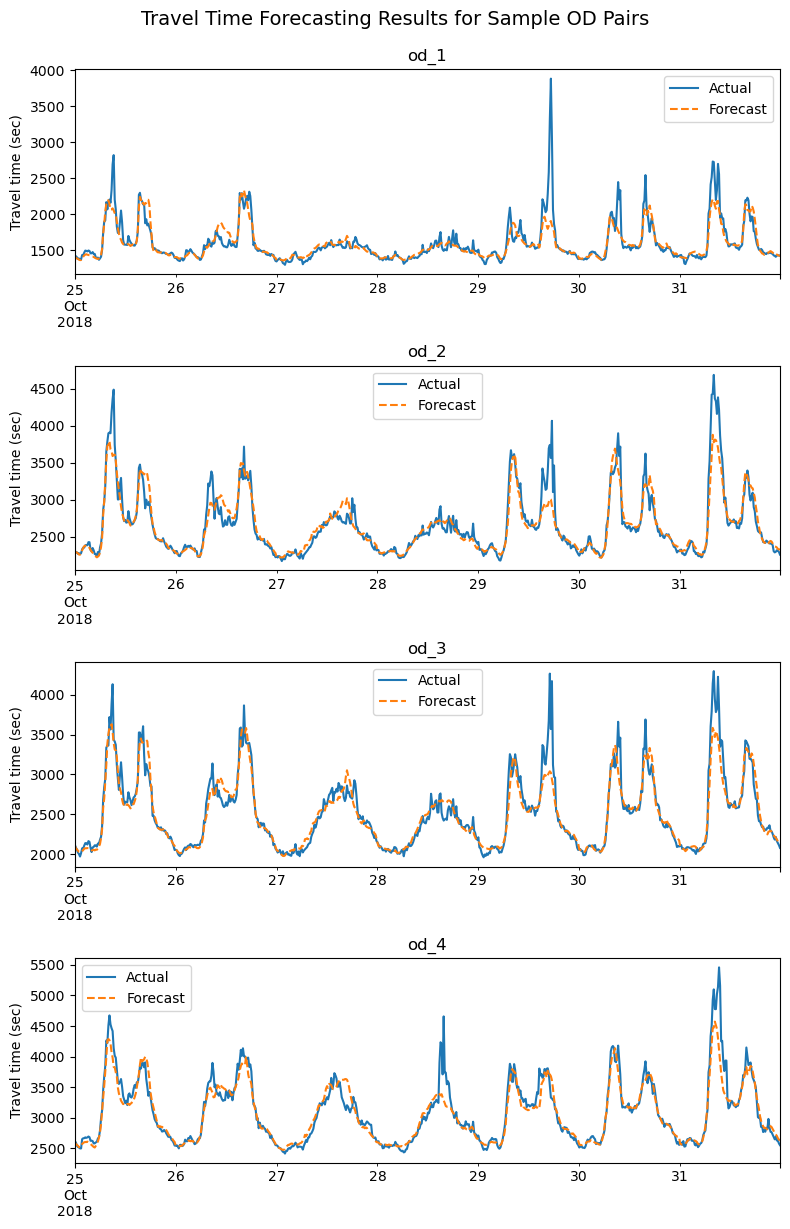

In [24]:
# Plot predictions
num_timeseries = 4

fig, axs = plt.subplots(nrows=num_timeseries, figsize=(8, 3*num_timeseries))

for i in range(num_timeseries):

    ts = target_cols[i]

    # actual values
    data_exog.loc[forecast_wide.index, ts].plot(
        ax=axs[i],
        label="Actual",
        legend=True
    )

    # forecast
    forecast_wide[ts].plot(
        ax=axs[i],
        label="Forecast",
        linestyle="--",
        legend=True
    )

    axs[i].set_title(ts)
    axs[i].set_xlabel("")
    axs[i].set_ylabel("Travel time (sec)")

plt.tight_layout()
plt.suptitle("Travel Time Forecasting Results for Sample OD Pairs", fontsize=14, y=1.02)
plt.show()

## 9. Baseline Comparison

To assess whether the machine learning model adds value, I compared it against a **seasonal naive baseline**:

$$
\hat{y}_t = y_{t-96}
$$

This baseline assumes that travel time at a given 15-minute interval will be similar to the same interval on the previous day.

In [26]:
# MAE of baseline

baseline_yday = data_exog[target_cols].shift(96).loc[forecast_wide.index]
y_true=data_exog.loc[forecast_wide.index,target_cols]


mae_baseline=mean_absolute_error(y_true,baseline_yday)
mape_baseline = mean_absolute_percentage_error(y_true, baseline_yday)

print("MAE:", mae_baseline)
print("MAPE:", mape_baseline)

MAE: 117.47560177917322
MAPE: 0.053508854073606976


In [27]:
improvement = (mae_baseline - mae) / mae_baseline * 100
print(f"Improvement over baseline: {improvement:.1f}%")

Improvement over baseline: 44.3%


## 10. Conclusion

This project developed a day-ahead travel time forecasting model for 182 OD pairs using a recursive multi-series machine learning approach.

### Key takeaways
- Temporal and rolling features improved the ability to capture traffic dynamics
- The LightGBM-based forecasting model outperformed the seasonal naive baseline
- Prediction accuracy was strongest during normal traffic periods and weaker around peak congestion hours

### Future Improvements
- incorporate spatial neighbor features between OD pairs
- test direct forecasting to reduce recursive error accumulation
- include richer external signals such as incidents or holiday effects